In [1]:
import numpy as np
import random 
import multiprocessing
import tensorflow as tf
import matplotlib.pyplot as plt
import sys
import copy

from cosmopower import cosmopower_NN
from scipy import interpolate
from scipy import signal

In [2]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu' 
print('using', device, 'device \n')

# setting the seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using cpu device 



In [4]:
path_to_train = '../../'
training_info_1 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-May20-list1.txt")
training_info_2 = np.loadtxt(path_to_train + "output/emulator-train-cross-allparams-May20-list2.txt")

In [5]:
training_info_1and2 = np.concatenate((training_info_1, training_info_2), axis=0)

print(np.shape(training_info_1and2))

(1500, 171)


In [6]:
param_indices = [0,5,1,2,3]
training_info = np.ndarray(shape=(len(training_info_1and2),149))
training_info[:,:5] = training_info_1and2[:,param_indices]
training_info[:,5::4] = training_info_1and2[:,25:169:4]
training_info[:,6::4] = training_info_1and2[:,26:169:4]
training_info[:,7::4] = training_info_1and2[:,27:169:4]
training_info[:,8::4] = training_info_1and2[:,28:169:4]

In [7]:
print(np.shape(training_info))
lx = []
for i in range(len(training_info)):
    ss = 0
    for j in range(len(training_info[0])):
        if (np.isnan(training_info[i][j]) or training_info[i][j]<0) and ss == 0:
            #print(i)
            ss = 1
    if ss == 0:
        lx.append(i)

lx = np.array(lx)
#print(len(lx))
training_info = training_info[lx,:]
print(np.shape(training_info))

(1500, 149)
(1473, 149)


In [8]:
print(np.shape(training_info))

training_params = training_info[:,:5]
training_data = training_info[:,5:]

print(np.shape(training_params))
print(np.shape(training_data))

#np.save('test_params_map3_b', training_params[400:])
#np.save('test_true_vals_map3_b', training_data[400:])

(1473, 149)
(1473, 5)
(1473, 144)


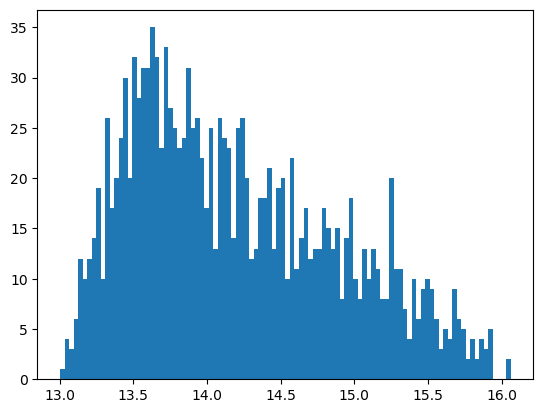

In [9]:
plt.hist(np.log10(training_data[:,100]), bins=100)
plt.show()

In [10]:
#initial try for pre-processing
#histogram of logs is less skewed than values
#try taking log10 and doing min-max after that

def log_and_norm(array):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minv = np.min(tmp)
        maxv = np.max(tmp)
        out_array[:,i] = (tmp-minv*np.ones(samples))/(maxv-minv)
        minv_arr[i] = minv
        maxv_arr[i] = maxv
        
    return(out_array, minv_arr, maxv_arr) 

In [11]:
def log_and_norm_test_set(array, minn, maxx):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    minv_arr = np.zeros(len(array[0]))
    maxv_arr = np.zeros(len(array[0]))
    
    for i in range(len(array[0])):
        tmp = np.log10(array[:,i])
        minni = minn[i]
        maxxi = maxx[i]
        out_array[:,i] = (tmp-minni*np.ones(len(tmp)))/(maxxi-minni)
        
    return(out_array)

In [12]:
def post_process(array, minv_arr, maxv_arr):
    
    out_array = np.zeros_like(array)
    samples = len(array)
    
    for i in range(len(array[0])):
        tmp = array[:,i]*(maxv[i]-minv[i])+minv[i]
        out_array[:,i] = 10**(tmp)
    
    return(out_array)

In [13]:
processed_data, minv, maxv = log_and_norm(training_data[:1300])
#plt.hist(processed_data[:,0], bins=100)
#plt.show()

In [85]:
print(training_params[1440])

[0.46270508 0.75046387 0.69642578 0.03283203 0.98416016]


In [14]:
import random

Omega_m = training_params[:1300,0]
s8 = training_params[:1300,1]
h0 = training_params[:1300,2]
Omega_b = training_params[:1300,3]
n_s = training_params[:1300,4]

smallest_om = np.min(Omega_m)
biggest_om = np.max(Omega_m)
Omega_m = (Omega_m - smallest_om)/(biggest_om - smallest_om)

smallest_s8 = np.min(s8)
biggest_s8 = np.max(s8)
s8 = (s8 - smallest_s8)/(biggest_s8 - smallest_s8)

smallest_h0 = np.min(h0)
biggest_h0 = np.max(h0)
h0 = (h0 - smallest_h0)/(biggest_h0 - smallest_h0)

smallest_ob = np.min(Omega_b)
biggest_ob = np.max(Omega_b)
Omega_b = (Omega_b - smallest_ob)/(biggest_ob - smallest_ob)

smallest_ns = np.min(n_s)
biggest_ns = np.max(n_s)
n_s = (n_s - smallest_ns)/(biggest_ns - smallest_ns)

In [15]:
import pickle

omega_m_keys = {'small': smallest_om, 'large': biggest_om}
s8_keys = {'small': smallest_s8, 'large': biggest_s8}
h0_keys = {'small': smallest_h0, 'large': biggest_h0}
omega_b_keys = {'small': smallest_ob, 'large': biggest_ob}
ns_keys = {'small': smallest_ns, 'large': biggest_ns}
params_rescale = {'Omega_m': omega_m_keys, 's8': s8_keys, 'h0': h0_keys, 'Omega_b': omega_b_keys, 'ns':ns_keys}
feature_rescale = {'small': minv, 'large': maxv}
dict_rescale_full = {'params': params_rescale, 'features': feature_rescale}
file_path = 'rescaling_for_map3_network_22May24.pkl'
with open(file_path, 'wb') as file:
    pickle.dump(dict_rescale_full, file)

### Load training parameters and spectra

In [16]:
modes = np.arange(144)

In [17]:
train_params = {'Omega_m': Omega_m,
          's8': s8,'h0': h0, 'Omega_b': Omega_b, 'ns': n_s,
           }

In [18]:
target_data = {'features': processed_data,
               'minimum': minv,
               'maximum': maxv
}

### Training

In [19]:
# instantiate NN class
cp_nn = cosmopower_NN(parameters=['Omega_m', 's8', 'h0', 'Omega_b', 'ns'], 
                      modes=modes, 
                      n_hidden = [64, 256, 1024, 1024, 384, 192],
                      verbose=True,
                     )


Initialized cosmopower_NN model, 
mapping 5 input parameters to 144 output modes, 
using 6 hidden layers, 
with [64, 256, 1024, 1024, 384, 192] nodes, respectively. 



In [ ]:
#noisy_input_data = np.zeros(shape=(900,80))
#for i in range(80):
#    noisy_input_data[:,i] = processed_data[:900, i] + np.random.normal(scale=0.05, size = 900)

In [20]:
with tf.device(device):
    # train
    cp_nn.train(training_parameters=train_params,
                training_features=processed_data,
                #training_features=noisy_input_data,
                filename_saved_model='map3_model_22May24-0',
                # cooling schedule
                validation_split=0.25,
                learning_rates=[0.01, 0.001, 0.0001, 0.00001, 0.000001],
                #learning_rates=[0.01, 0.01, 0.01, 0.01],
                batch_sizes=[60, 30, 20, 10, 5],
                gradient_accumulation_steps = [1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [200,200,150,100, 100],
                max_epochs = [2000, 2000, 2000, 2000, 2000],
                )

Starting cosmopower_NN training, 
using 25 per cent of training samples for validation. 
Performing 5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] learning rates 
[60, 30, 20, 10, 5] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps 
[200, 200, 150, 100, 100] patience values 
[2000, 2000, 2000, 2000, 2000] max epochs 

learning rate = 0.01, batch size = 60


 71%|█████████████████▊       | 1428/2000 [11:46<04:43,  2.02it/s, loss=0.00273]


Validation loss = 0.00210559
Model saved.
Reached max number of epochs. Validation loss = 0.00210559
Model saved.
learning rate = 0.001, batch size = 30


 26%|██████▍                  | 513/2000 [07:15<21:03,  1.18it/s, loss=0.000526]


Validation loss = 0.00033053648
Model saved.
Reached max number of epochs. Validation loss = 0.00033053648
Model saved.
learning rate = 0.0001, batch size = 20


...

Validation loss = 0.00011814428
Model saved.
Reached max number of epochs. Validation loss = 0.00011814428
Model saved.
learning rate = 1e-05, batch size = 10


  5%|█▏                      | 100/2000 [04:05<1:17:36,  2.45s/it, loss=9.64e-5]


Validation loss = 8.8790635e-05
Model saved.
Reached max number of epochs. Validation loss = 8.8790635e-05
Model saved.
learning rate = 1e-06, batch size = 5


  5%|█▏                      | 100/2000 [07:39<2:25:29,  4.59s/it, loss=7.42e-5]

Validation loss = 7.054484e-05
Model saved.
Reached max number of epochs. Validation loss = 7.054484e-05
Model saved.


In [21]:
Omega_m_test = (training_params[1300:,0]-smallest_om)/(biggest_om-smallest_om)
s8_test = (training_params[1300:,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_test = (training_params[1300:,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_test = (training_params[1300:,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_test = (training_params[1300:,4]-smallest_ns)/(biggest_ns-smallest_ns)

print(len(training_params[:,0]))
print(len(Omega_m_test))
the_test_dict = {'Omega_m': Omega_m_test,
          's8': s8_test,
                 'h0': h0_test,
                 'Omega_b': Omega_b_test,
                 'ns': ns_test,
           }
    
predictions = cp_nn.predictions_np(the_test_dict)

1473
173


In [22]:
test_set_new_scale = log_and_norm_test_set(training_data[1300:], minv, maxv)

In [23]:
predictions_rescaled = post_process(predictions, minv, maxv)

In [24]:
print(predictions_rescaled[:,0]-training_data[1300:,0])

[-1.49438907e+05  2.64111782e+04 -3.65655714e+04  1.81516150e+04
  4.97606689e+04 -3.40390338e+05 -1.06234723e+05  2.36940805e+05
  1.01005049e+05  4.37965635e+05 -4.20712411e+04 -6.18398408e+05
 -2.69789651e+05 -3.07141164e+04 -3.19984795e+05 -1.90791372e+04
  1.76323968e+05 -1.80656473e+05  4.81482214e+04 -1.99731402e+05
  7.85192576e+04  6.77776165e+03  2.20490245e+05 -7.81454046e+04
 -7.89256137e+03 -3.81205054e+04  1.82164688e+05 -1.07225512e+05
 -2.35189809e+04  7.98009524e+04  1.61375553e+05  1.17323784e+05
 -1.06754542e+05 -4.88424612e+04  2.46584135e+05  2.39557955e+05
 -1.60117559e+05  3.40298032e+04 -7.35245847e+04 -1.34632078e+06
  1.38499019e+04  1.57295117e+02  1.11434334e+05 -1.44933297e+05
  4.21128172e+04  3.61177140e+05 -1.83912912e+05  1.76164406e+05
 -1.23853581e+05 -5.56400781e+05 -3.10244261e+05  2.69775535e+04
 -1.60024989e+04 -7.84051459e+05 -3.31461397e+04  1.30409043e+06
  9.46127578e+04  8.65950646e+04 -1.80465196e+05 -3.43656249e+05
  1.56918353e+04  6.01377

In [25]:
mse = np.mean((predictions[:,0]-test_set_new_scale[:,0])**2)

In [26]:
print(mse)

6.4614447036421e-08


In [27]:
print(predictions_rescaled[:,0])
print(training_data[1300:])

[1.59921210e+08 5.03986845e+08 1.50144037e+08 3.98437216e+08
 3.70047455e+08 8.59031933e+08 2.19600120e+08 3.58026351e+08
 8.21375304e+07 1.30028878e+08 8.45634342e+07 2.57377598e+09
 1.78880004e+08 2.86774908e+08 2.46113704e+08 2.43455599e+08
 6.38365577e+07 2.50762319e+08 9.17096482e+07 1.72702419e+09
 2.66855976e+08 1.67731684e+08 2.57819418e+08 1.45643443e+08
 1.94506989e+08 7.52523196e+08 2.12687235e+08 8.51154100e+08
 1.42965431e+08 6.03543356e+08 1.84636991e+08 6.85361004e+08
 9.60570691e+07 1.95252676e+08 1.19558374e+08 3.16853339e+08
 1.64571731e+08 6.10307396e+08 4.09859487e+08 9.64477051e+08
 1.12411720e+08 2.57693431e+08 1.45636049e+08 2.34318060e+08
 5.55282230e+07 1.19005085e+09 7.11422950e+07 9.49553132e+08
 4.78405966e+08 2.24415960e+08 9.85881320e+07 2.97669034e+08
 1.25659698e+08 1.37133274e+09 1.21536316e+08 1.59874799e+09
 2.61647475e+08 3.16488893e+08 4.79088028e+08 9.47654977e+08
 7.03246471e+07 2.80068414e+08 1.94991736e+08 3.71083811e+08
 2.57944846e+08 1.864208

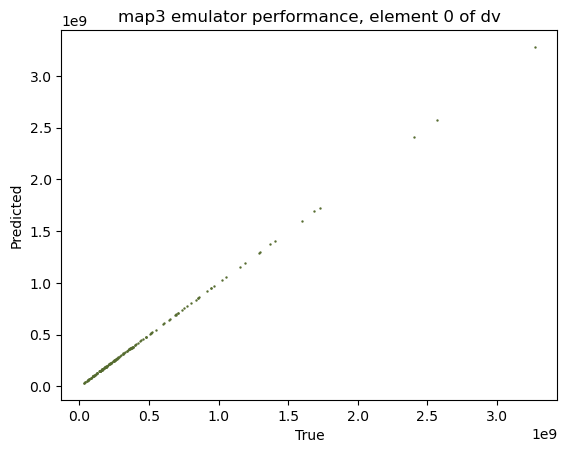

In [28]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(training_data[1300:,0],predictions_rescaled[:,0], s=0.5, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [29]:
test_data_all = training_data[1300:].flatten()
pred_rescaled_all = predictions_rescaled.flatten()

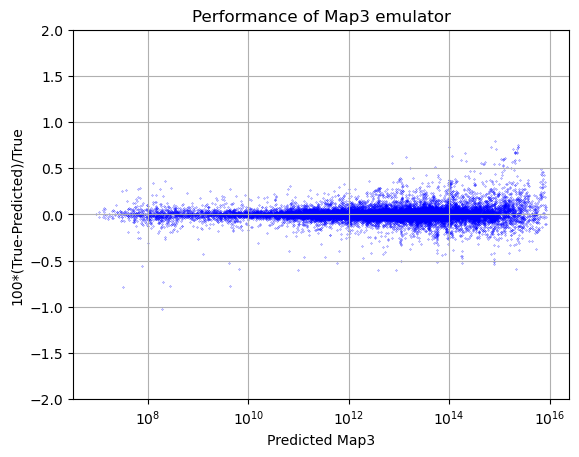

In [30]:
plt.title("Performance of Map3 emulator")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_data_all,100*(pred_rescaled_all-test_data_all)/test_data_all, s=0.05, color='b')
plt.ylim(-2,2)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.grid()
plt.show()
#plt.savefig('Percentual_difference_map3emulator_13May24-0.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,0], predictions[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
all_true = test_set_new_scale.flatten()
all_pred = predictions.flatten()

In [ ]:
plt.title("map3 emulator performance, all elements of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred, s=0.5)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("emulator performance before los integration, all cosmo params")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(all_true, all_pred-all_true, s=0.05, color='darkolivegreen')
plt.xlabel("True")
plt.ylabel("Predicted-True")
#plt.show()
plt.savefig('all_cosmo_params_emulator_performance.png')

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(test_set_new_scale[:,42], predictions[:,42]-test_set_new_scale[:,42], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
#plt.scatter(processed_data[900:,1], predictions[:,1], s=2)
#plt.scatter(training_params[:,0], training_data[:,0], s=2)
plt.scatter(np.log10(training_data[1300:,35]), np.log10(predictions_rescaled[:,35]), s=2)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

In [ ]:
plt.title("map3 emulator performance, element 0 of dv")
plt.scatter(training_data[900:,1],-training_data[900:,1]+predictions_rescaled[:,1], s=2)
#plt.scatter(training_data[900:,0], predictions_rescaled[:,0], s=2)
plt.xlabel("True")
plt.ylabel("Predicted-True")
plt.show()
#plt.savefig("Map3_emulator_scatter_diff.png")

In [86]:
#test with single param. COSMO1 = n200. COSMO 2 = [0.46270508 0.75046387 0.69642578 0.03283203 0.98416016] (n1440)
Omega_m_sp = (training_params[1440:1441,0]-smallest_om)/(biggest_om-smallest_om)
s8_sp = (training_params[1440:1441,1]-smallest_s8)/(biggest_s8-smallest_s8)
h0_sp = (training_params[1440:1441,2]-smallest_h0)/(biggest_h0-smallest_h0)
Omega_b_sp = (training_params[1440:1441,3]-smallest_ob)/(biggest_ob-smallest_ob)
ns_sp = (training_params[1440:1441,4]-smallest_ns)/(biggest_ns-smallest_ns)

#print(len(training_params[:,0]))
#print(len(Omega_m_test))
the_test_dict_sp = {'Omega_m': Omega_m_sp,
          's8': s8_sp,
                 'h0': h0_sp,
                 'Omega_b': Omega_b_sp,
                 'ns': ns_sp,
           }
    
predictions_sp = cp_nn.predictions_np(the_test_dict_sp)

In [87]:
predictions_rescaled_sp = post_process(predictions_sp, minv, maxv)

In [88]:
print(np.shape(training_data[1440]))

(144,)


In [91]:
save_true = np.zeros(shape=(1,144))
save_pred = np.zeros(shape=(1,144))
save_true[0] = training_data[1440]
save_pred[0] = predictions_rescaled_sp
#print((training_data[1440]-predictions_rescaled_sp)/training_data[1440])
np.save("true_value_cosmo2", save_true)
np.save("pred_value_cosmo2", save_pred)

In [41]:
print(np.shape(predictions_rescaled_sp))

(1, 144)


In [37]:
print(np.shape(predictions_rescaled_sp[0,0::4]))

(36,)


In [92]:
filter_1_info = training_data[1440][0::4]
filter_2_info = training_data[1440][1::4]
filter_3_info = training_data[1440][2::4]
filter_4_info = training_data[1440][3::4]
zarray1 = np.array([0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07])
zarray2 = np.linspace(0.1, 1.5, num = 29)
zarray = np.concatenate((zarray1, zarray2))

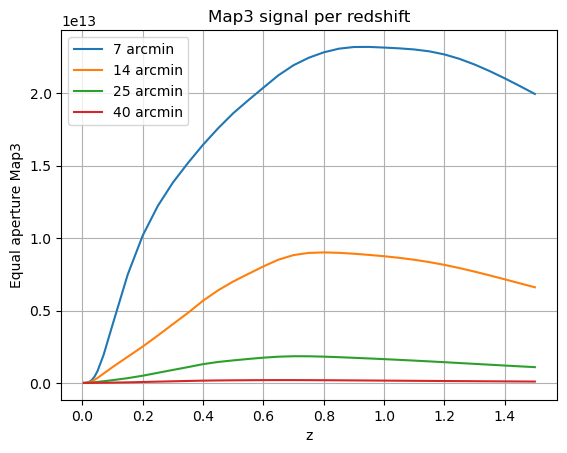

In [93]:
import matplotlib.pyplot as plt

plt.title("Map3 signal per redshift")
plt.xlabel("z")
plt.ylabel("Equal aperture Map3")
plt.plot(zarray, filter_1_info, label='7 arcmin')
plt.plot(zarray, filter_2_info, label='14 arcmin')
plt.plot(zarray, filter_3_info, label='25 arcmin')
plt.plot(zarray, filter_4_info, label='40 arcmin')
plt.grid()
plt.legend()
plt.show()

In [60]:
test_data_lowz_7arcmin = training_data[1300:][0:32:4].flatten()
pred_rescaled_lowz_7arcmin = predictions_rescaled[0:32:4].flatten()

In [61]:
test_data_lowz_14arcmin = training_data[1300:][1:32:4].flatten()
pred_rescaled_lowz_14arcmin = predictions_rescaled[1:32:4].flatten()

In [64]:
test_data_lowz_25arcmin = training_data[1300:][2:32:4].flatten()
pred_rescaled_lowz_25arcmin = predictions_rescaled[2:32:4].flatten()

In [65]:
test_data_lowz_40arcmin = training_data[1300:][3:32:4].flatten()
pred_rescaled_lowz_40arcmin = predictions_rescaled[3:32:4].flatten()

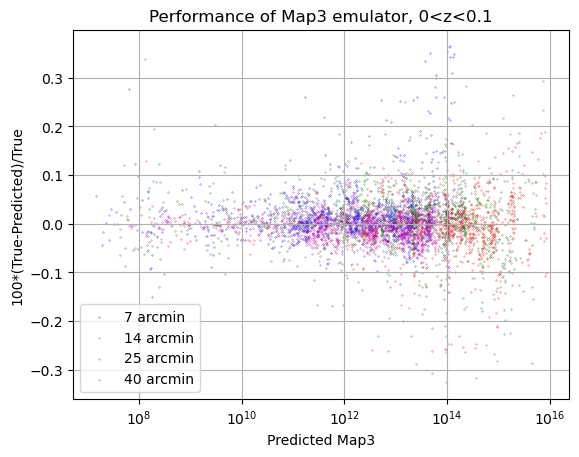

In [77]:
plt.title("Performance of Map3 emulator, 0<z<0.1")
plt.scatter(test_data_lowz_7arcmin,100*(pred_rescaled_lowz_7arcmin-test_data_lowz_7arcmin)/test_data_lowz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_lowz_14arcmin,100*(pred_rescaled_lowz_14arcmin-test_data_lowz_14arcmin)/test_data_lowz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_lowz_25arcmin,100*(pred_rescaled_lowz_25arcmin-test_data_lowz_25arcmin)/test_data_lowz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_lowz_40arcmin,100*(pred_rescaled_lowz_40arcmin-test_data_lowz_40arcmin)/test_data_lowz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [67]:
test_data_midz_7arcmin = training_data[1300:][32:80:4].flatten()
pred_rescaled_midz_7arcmin = predictions_rescaled[32:80:4].flatten()
test_data_midz_14arcmin = training_data[1300:][33:80:4].flatten()
pred_rescaled_midz_14arcmin = predictions_rescaled[33:80:4].flatten()
test_data_midz_25arcmin = training_data[1300:][34:80:4].flatten()
pred_rescaled_midz_25arcmin = predictions_rescaled[34:80:4].flatten()
test_data_midz_40arcmin = training_data[1300:][35:80:4].flatten()
pred_rescaled_midz_40arcmin = predictions_rescaled[35:80:4].flatten()

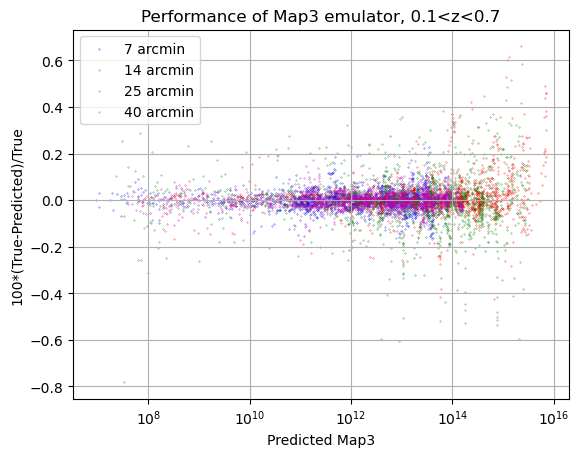

In [76]:
plt.title("Performance of Map3 emulator, 0.1<z<0.7")
plt.scatter(test_data_midz_7arcmin,100*(pred_rescaled_midz_7arcmin-test_data_midz_7arcmin)/test_data_midz_7arcmin, s=0.05, color='b', label='7 arcmin')
plt.scatter(test_data_midz_14arcmin,100*(pred_rescaled_midz_14arcmin-test_data_midz_14arcmin)/test_data_midz_14arcmin, s=0.05, color='r', label='14 arcmin')
plt.scatter(test_data_midz_25arcmin,100*(pred_rescaled_midz_25arcmin-test_data_midz_25arcmin)/test_data_midz_25arcmin, s=0.05, color='g', label='25 arcmin')
plt.scatter(test_data_midz_40arcmin,100*(pred_rescaled_midz_40arcmin-test_data_midz_40arcmin)/test_data_midz_40arcmin, s=0.05, color='m', label='40 arcmin')
#plt.ylim(-0.5,0.5)
plt.ylabel("100*(True-Predicted)/True")
plt.xscale('log')
plt.xlabel("Predicted Map3")
plt.legend()
plt.grid()
plt.show()

In [99]:
path_to_train = '../../'
cosmo2_morez = np.loadtxt(path_to_train + "output/true-map3-vals-cosmo2.txt")[25:-2]
print(np.shape(cosmo2_morez))

(256,)


In [102]:
save_true_finez = np.zeros(shape=(1,256))
save_true_finez[0] = cosmo2_morez
np.save("true_value_cosmo2_fine_z", save_true_finez)